# 03 - Modelo DL Clássico: LSTM
O LSTM (Long Short-Term Memory) é uma rede neural recorrente capaz de aprender dependências de longo prazo em sequências de texto. Foi escolhido por sua capacidade de capturar o contexto e a ordem das palavras em e-mails, o que é fundamental para identificar padrões de phishing.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f"TensorFlow versão: {tf.__version__}")
print("Bibliotecas carregadas!")

TensorFlow versão: 2.21.0
Bibliotecas carregadas!


In [4]:
# Carrega o dataset limpo
df = pd.read_csv('../data/phishing_email_limpo.csv')

print(f"Dataset carregado: {df.shape}")
df.head()

Dataset carregado: (82403, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [5]:
# Define o tamanho do vocabulário e o tamanho máximo de cada e-mail
VOCAB_SIZE = 10000  # as 10000 palavras mais frequentes
MAX_LEN = 200       # máximo de 200 palavras por e-mail

# Tokenizador: transforma cada palavra em um número
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_combined'])

# Transforma os textos em sequências de números
sequences = tokenizer.texts_to_sequences(df['text_combined'])

# Padeia as sequências para todas terem o mesmo tamanho
X = pad_sequences(sequences, maxlen=MAX_LEN, truncating='post', padding='post')
y = df['label'].values

print(f"Shape dos dados: {X.shape}")
print(f"Exemplo de e-mail tokenizado: {X[0][:20]}...")

Shape dos dados: (82403, 200)
Exemplo de e-mail tokenizado: [ 831 2454   23  204   74   57  351   98 7386    1 1958 7386    1 1958
    0    0    0    0    0    0]...


In [6]:
# Divide o dataset: 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]} e-mails")
print(f"Teste:  {X_test.shape[0]} e-mails")

Treino: 65922 e-mails
Teste:  16481 e-mails


In [7]:
# Constrói o modelo sequencial camada por camada
model = Sequential([
    # Embedding: transforma os números em vetores densos de 64 dimensões
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN),
    
    # LSTM: aprende os padrões na sequência de palavras
    LSTM(64, return_sequences=False),
    
    # Dropout: desliga 50% dos neurônios aleatoriamente para evitar overfitting
    Dropout(0.5),
    
    # Camada de saída: 1 neurônio com sigmoid (saída entre 0 e 1)
    Dense(1, activation='sigmoid')
])

# Compila o modelo definindo otimizador, função de perda e métrica
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Exibe o resumo da arquitetura
model.summary()

C:\Users\pedri\Desktop\Projeto de IA\phishing-detector\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Treina o modelo por 5 épocas com lotes de 64 e-mails
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,  # 10% do treino vira validação
    verbose=1
)

print("Treinamento concluído!")

Epoch 1/5
928/928 ━━━━━━━━━━━━━━━━━━━━ 201s 210ms/step - accuracy: 0.7473 - loss: 0.5093 - val_accuracy: 0.7253 - val_loss: 0.5089
Epoch 2/5
928/928 ━━━━━━━━━━━━━━━━━━━━ 199s 214ms/step - accuracy: 0.6633 - loss: 0.5755 - val_accuracy: 0.8905 - val_loss: 0.2882
Epoch 3/5
928/928 ━━━━━━━━━━━━━━━━━━━━ 211s 227ms/step - accuracy: 0.9498 - loss: 0.1795 - val_accuracy: 0.9685 - val_loss: 0.1116
Epoch 4/5
928/928 ━━━━━━━━━━━━━━━━━━━━ 215s 231ms/step - accuracy: 0.9683 - loss: 0.1045 - val_accuracy: 0.9769 - val_loss: 0.0733
Epoch 5/5
928/928 ━━━━━━━━━━━━━━━━━━━━ 215s 232ms/step - accuracy: 0.9835 - loss: 0.0568 - val_accuracy: 0.9832 - val_loss: 0.0539
Treinamento concluído!


In [9]:
# Faz previsões no conjunto de teste
y_pred_prob = model.predict(X_test)

# Converte probabilidades para 0 ou 1 (threshold de 50%)
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Acurácia: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Phishing']))

516/516 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step
Acurácia: 98.37%

Relatório de Classificação:
              precision    recall  f1-score   support

    Legítimo       0.99      0.98      0.98      8027
    Phishing       0.98      0.99      0.98      8454

    accuracy                           0.98     16481
   macro avg       0.98      0.98      0.98     16481
weighted avg       0.98      0.98      0.98     16481



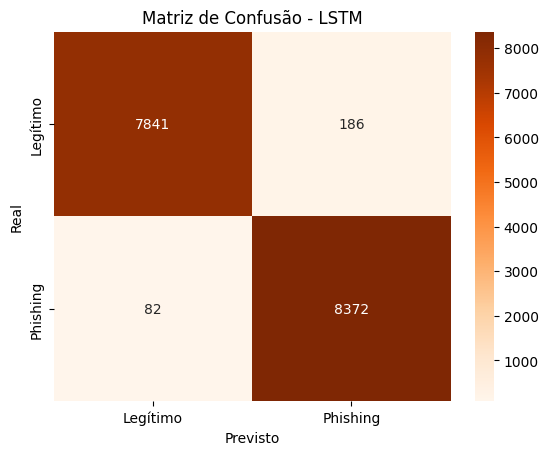

In [10]:
# Gera e plota a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legítimo', 'Phishing'],
            yticklabels=['Legítimo', 'Phishing'])

plt.title('Matriz de Confusão - LSTM')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

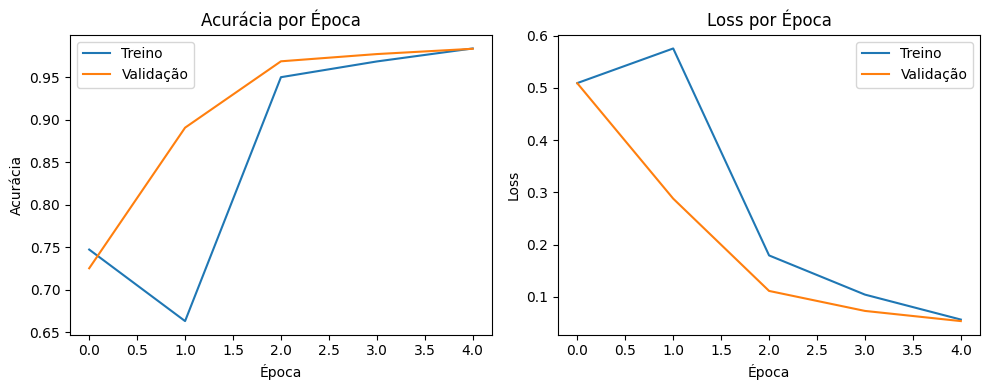

In [11]:
# Plota a evolução da acurácia ao longo das épocas
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
import joblib

# Salva o modelo LSTM
model.save('../models/lstm_model.keras')

# Salva o tokenizador para usar no Streamlit depois
joblib.dump(tokenizer, '../models/lstm_tokenizer.pkl')

print("Modelo e tokenizador salvos!")

Modelo e tokenizador salvos!
